# ETC Impacts on the Great Lakes: Figure 4 Genesis Maps

This notebook generates the genesis-density maps used for Figure 4. It loads the labeled storm table from the `processed/` directory, subsets storms by storm type and season, and produces both individual genesis-density maps and a 2×2 summary panel.

This notebook may be easiest to run in Google Colab if Cartopy is not available locally. When run locally, it may require Cartopy to download Natural Earth shapefiles the first time it is used.

In [1]:
# ------------------------------
# 1. Colab setup (only if needed)
# ------------------------------
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install cartopy shapely pyproj certifi

In [2]:
# ------------------------------
# 2. Imports, SSL setup, and paths
# ------------------------------
from pathlib import Path
import os
import certifi

# Force Python/urllib to use certifi's CA bundle
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/gdrive")
    BASE_DIR = Path("/content/gdrive/MyDrive/ETC Clustering Paper")
else:
    BASE_DIR = Path.cwd().resolve().parent

PROCESSED_DIR = BASE_DIR / "processed"
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

CSV_PATH = PROCESSED_DIR / "cfsr_storms_labeled_k2.csv"

## Load labeled storm table

We use the labeled CFSR storm table generated in the clustering notebook. This notebook assumes that the `storm_type` column has already been assigned consistently in the saved processed file.

In [3]:
# ------------------------------
# 3. Load data
# ------------------------------
df = pd.read_csv(CSV_PATH)

assert "storm_type" in df.columns, "storm_type not found. Re-run 02_build_gmm_model.ipynb."
required_cols = {"lon_gen", "lat_gen", "storm_type", "season"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in input file: {sorted(missing)}")

TYPE1 = "Type 1 (Earlier-entry storms)"
TYPE2 = "Type 2 (Later-entry storms)"

print("Loaded dataframe shape:", df.shape)
print(df["storm_type"].value_counts(dropna=False))

Loaded dataframe shape: (3316, 36)
storm_type
Type 1 (Earlier-entry storms)    1903
Type 2 (Later-entry storms)      1413
Name: count, dtype: int64


 ## Map settings and metadata

In [4]:
# ------------------------------
# 4. Map settings and metadata
# ------------------------------
lon_min, lon_max = -130, -66
lat_min, lat_max = 24, 65

GLR_BOX = (-92.0, 41.0, 17.0, 8.5)

SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
TYPE_ORDER = [TYPE1, TYPE2]

TYPE_SHORT = {
    TYPE1: "type1_earlier",
    TYPE2: "type2_later",
}

SEASON_LONG = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Fall",
}

In [5]:
# ------------------------------
# 5. Plot helpers
# ------------------------------
def save_figure_both(fig, filename_base: str):
    png_path = FIG_DIR / f"{filename_base}.png"
    pdf_path = FIG_DIR / f"{filename_base}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.close(fig)
    return png_path, pdf_path


def setup_ax(ax):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, alpha=0.25)
    ax.add_feature(cfeature.OCEAN, alpha=0.15)
    ax.add_feature(cfeature.LAKES, alpha=0.55)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        color="k",
        alpha=0.25,
        linestyle="--",
        linewidth=0.5,
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}


def smooth2d(H, iters=2):
    K = np.array(
        [
            [1, 2, 1],
            [2, 4, 2],
            [1, 2, 1],
        ],
        dtype=float,
    )
    K /= K.sum()

    A = H.astype(float)
    for _ in range(iters):
        P = np.pad(A, 1, mode="edge")
        A = (
            K[0, 0] * P[:-2, :-2] + K[0, 1] * P[:-2, 1:-1] + K[0, 2] * P[:-2, 2:] +
            K[1, 0] * P[1:-1, :-2] + K[1, 1] * P[1:-1, 1:-1] + K[1, 2] * P[1:-1, 2:] +
            K[2, 0] * P[2:, :-2] + K[2, 1] * P[2:, 1:-1] + K[2, 2] * P[2:, 2:]
        )
    return A

## 2×2 summary map

This figure compares genesis-density patterns for the two storm types in fall (SON) and summer (JJA). Density can be scaled either within panel or across the full figure.

In [6]:
# ------------------------------
# 6. Core function: 2x2 figure
# ------------------------------
def plot_genesis_density_2x2_son_jja(
    df: pd.DataFrame,
    seasons=("SON", "JJA"),
    storm_types=(TYPE1, TYPE2),
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    scaling="panel",
    filename_base="fig_genesis_density_2x2_son_jja_panelnorm",
):
    fig, axes = plt.subplots(
        nrows=2,
        ncols=2,
        figsize=(14, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=False,
    )

    panel_data = {}

    # First pass: compute raw grids
    for r, season in enumerate(seasons):
        for c, storm_type in enumerate(storm_types):
            d = df[
                (df["storm_type"] == storm_type) &
                (df["season"] == season)
            ].dropna(subset=["lon_gen", "lat_gen"]).copy()

            lon_bins = np.arange(lon_min, lon_max + dlon, dlon)
            lat_bins = np.arange(lat_min, lat_max + dlat, dlat)

            H, xedges, yedges = np.histogram2d(
                d["lon_gen"],
                d["lat_gen"],
                bins=[lon_bins, lat_bins],
            )

            H = H.T

            if smooth_iters > 0:
                H = smooth2d(H, iters=smooth_iters)

            panel_data[(r, c)] = {
                "H": H,
                "xedges": xedges,
                "yedges": yedges,
                "n": len(d),
                "season": season,
                "storm_type": storm_type,
            }

    # Scaling choice
    if scaling == "global":
        all_max = max(item["H"].max() for item in panel_data.values())
        all_max = all_max if all_max > 0 else 1.0

        for item in panel_data.values():
            Hnorm = item["H"] / all_max
            if np.any(Hnorm > 0):
                upper = np.quantile(Hnorm[Hnorm > 0], clip_q)
                item["Hplot"] = np.clip(Hnorm, 0, upper)
                item["panel_clip"] = upper
            else:
                item["Hplot"] = Hnorm
                item["panel_clip"] = 1.0
        cbar_label = f"Relative genesis density (common scale, clipped at {int(clip_q * 100)}th percentile)"

    elif scaling == "panel":
        for item in panel_data.values():
            hmax = item["H"].max()
            Hnorm = item["H"] / hmax if hmax > 0 else item["H"]
            if np.any(Hnorm > 0):
                upper = np.quantile(Hnorm[Hnorm > 0], clip_q)
                item["Hplot"] = np.clip(Hnorm, 0, upper)
                item["panel_clip"] = upper
            else:
                item["Hplot"] = Hnorm
                item["panel_clip"] = 1.0
        cbar_label = f"Relative genesis density (panel-normalized, clipped at {int(clip_q * 100)}th percentile)"
    else:
        raise ValueError("scaling must be 'panel' or 'global'")

    mappable = None

    for r in range(2):
        for c in range(2):
            ax = axes[r, c]
            setup_ax(ax)

            item = panel_data[(r, c)]
            Hplot = item["Hplot"]
            xedges = item["xedges"]
            yedges = item["yedges"]
            n = item["n"]
            season = item["season"]
            storm_type = item["storm_type"]

            X, Y = np.meshgrid(xedges, yedges)

            pm = ax.pcolormesh(
                X,
                Y,
                Hplot,
                transform=ccrs.PlateCarree(),
                shading="auto",
                alpha=1.0,
                cmap="Purples",
                vmin=0,
                vmax=item["panel_clip"] if scaling == "panel" else 1,
            )
            mappable = pm

            rect = Rectangle(
                (GLR_BOX[0], GLR_BOX[1]),
                GLR_BOX[2],
                GLR_BOX[3],
                fill=False,
                linewidth=2.0,
                edgecolor="k",
                transform=ccrs.PlateCarree(),
            )
            ax.add_patch(rect)

            ax.text(
                GLR_BOX[0] + 0.7,
                GLR_BOX[1] + GLR_BOX[3] - 0.8,
                "GLR",
                fontsize=11,
                weight="bold",
                transform=ccrs.PlateCarree(),
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.0),
            )

            season_name = SEASON_LONG.get(season, season)
            ax.set_title(f"{storm_type}, {season_name} (n={n})", fontsize=12)

    panel_labels = ["(a)", "(b)", "(c)", "(d)"]
    for ax, label in zip(axes.flatten(), panel_labels):
        ax.text(
            -0.08,
            1.05,
            label,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top",
            ha="left",
            clip_on=False,
        )

    fig.subplots_adjust(right=0.88, wspace=0.12, hspace=0.18)
    cax = fig.add_axes([0.90, 0.20, 0.02, 0.60])
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(cbar_label)

    plt.show()
    return save_figure_both(fig, filename_base)

## Individual seasonal genesis maps

The functions below generate one genesis-density map for each storm type and season combination.

In [7]:
# ------------------------------
# 7. Core function: single panel
# ------------------------------
def plot_genesis_density_single(
    df: pd.DataFrame,
    storm_type: str,
    season: str,
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
    filename_base=None,
):
    d = df[
        (df["storm_type"] == storm_type) &
        (df["season"] == season)
    ].dropna(subset=["lon_gen", "lat_gen"]).copy()

    if d.empty:
        print(f"No storms found for {storm_type}, {season}")
        return None

    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    setup_ax(ax)

    lon_bins = np.arange(lon_min, lon_max + dlon, dlon)
    lat_bins = np.arange(lat_min, lat_max + dlat, dlat)

    H, xedges, yedges = np.histogram2d(
        d["lon_gen"],
        d["lat_gen"],
        bins=[lon_bins, lat_bins],
    )

    H = H.T

    if normalize and H.sum() > 0:
        H = H / H.sum()

    Hs = smooth2d(H, iters=smooth_iters)

    if np.any(Hs > 0):
        upper = np.quantile(Hs[Hs > 0], clip_q)
        Hplot = np.clip(Hs, 0, upper)
    else:
        Hplot = Hs

    X, Y = np.meshgrid(xedges, yedges)

    pm = ax.pcolormesh(
        X,
        Y,
        Hplot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        alpha=1.0,
        cmap="Purples",
        vmin=0,
    )

    cbar = fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02)
    if normalize:
        cbar.set_label(f"Genesis density (fraction per {dlon:.1f}° × {dlat:.1f}° grid cell)")
    else:
        cbar.set_label(f"Genesis count per {dlon:.1f}° × {dlat:.1f}° grid cell")

    rect = Rectangle(
        (GLR_BOX[0], GLR_BOX[1]),
        GLR_BOX[2],
        GLR_BOX[3],
        fill=False,
        linewidth=2.5,
        edgecolor="k",
        transform=ccrs.PlateCarree(),
    )
    ax.add_patch(rect)

    ax.text(
        GLR_BOX[0] + 0.7,
        GLR_BOX[1] + GLR_BOX[3] - 0.8,
        "GLR",
        fontsize=12,
        weight="bold",
        transform=ccrs.PlateCarree(),
        bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2.5),
    )

    season_name = SEASON_LONG.get(season, season)
    ax.set_title(f"{storm_type}, {season_name} (n={len(d)})", fontsize=14)
    fig.tight_layout()

    if filename_base is None:
        filename_base = f"fig_genesis_points_density_{season}"

    plt.show()
    return save_figure_both(fig, filename_base)

In [8]:
# ------------------------------
# 8. Batch function: all separate figures
# ------------------------------
def save_all_stormtype_season_figures(
    df: pd.DataFrame,
    seasons=SEASON_ORDER,
    storm_types=TYPE_ORDER,
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
):
    saved = []

    for season in seasons:
        for storm_type in storm_types:
            filename_base = f"fig_genesis_density_{TYPE_SHORT[storm_type]}_{season.lower()}"
            outpaths = plot_genesis_density_single(
                df=df,
                storm_type=storm_type,
                season=season,
                dlon=dlon,
                dlat=dlat,
                smooth_iters=smooth_iters,
                clip_q=clip_q,
                normalize=normalize,
                filename_base=filename_base,
            )
            if outpaths is not None:
                saved.append(outpaths)
                print("Saved:", outpaths)

    return saved

## Generate and save figures

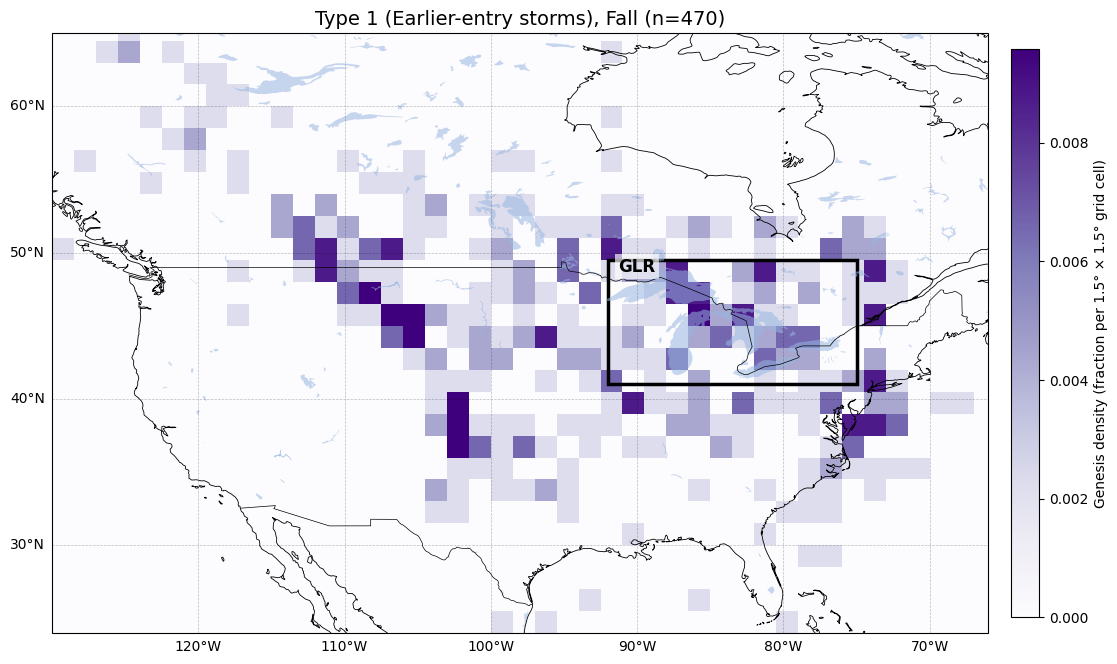

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_son.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_son.pdf'))


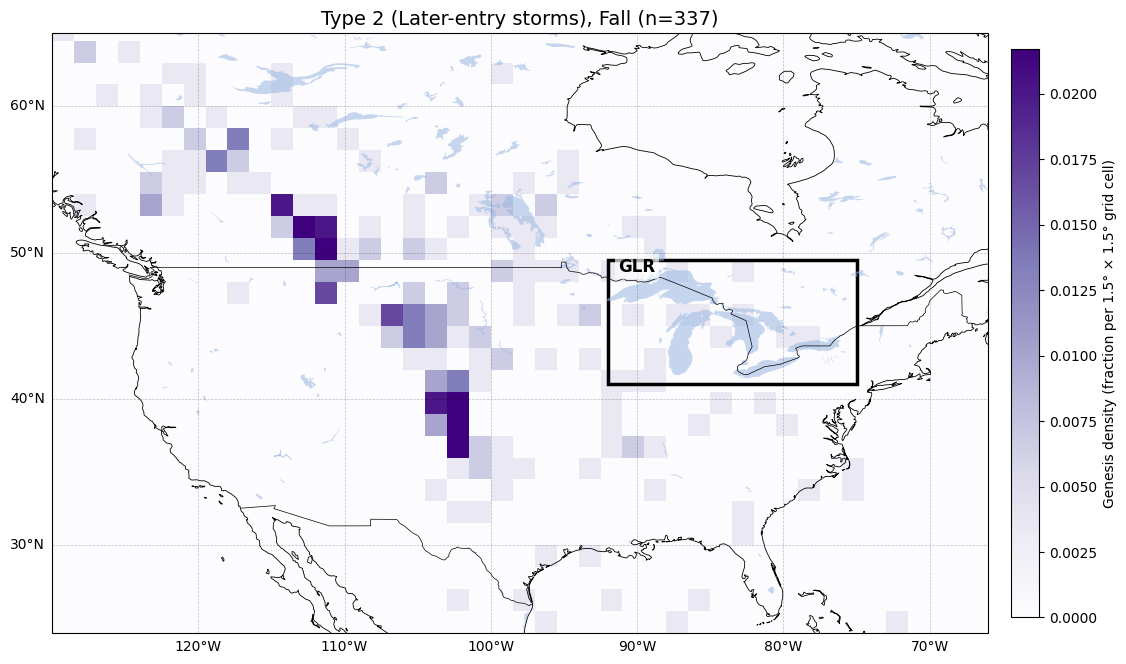

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_son.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_son.pdf'))


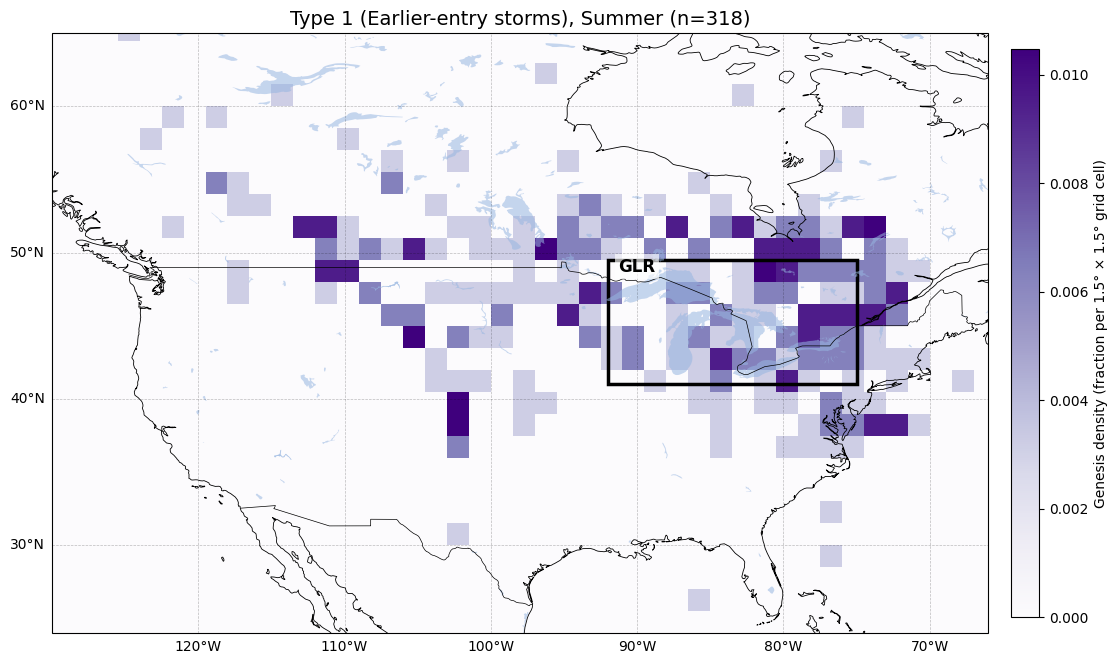

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_jja.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_jja.pdf'))


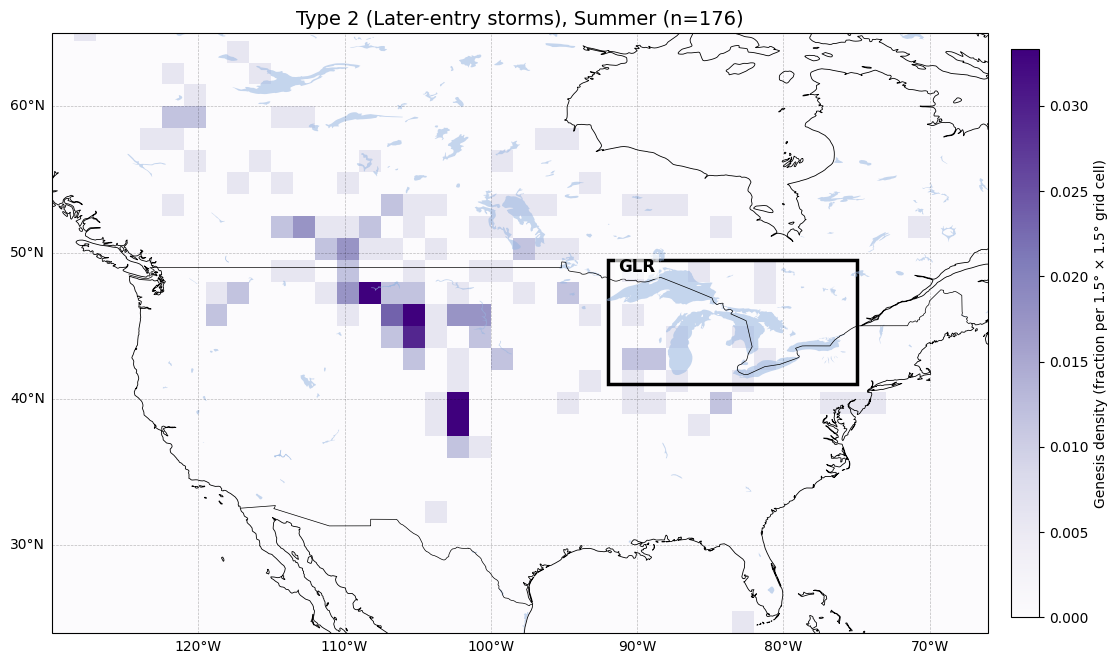

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_jja.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_jja.pdf'))


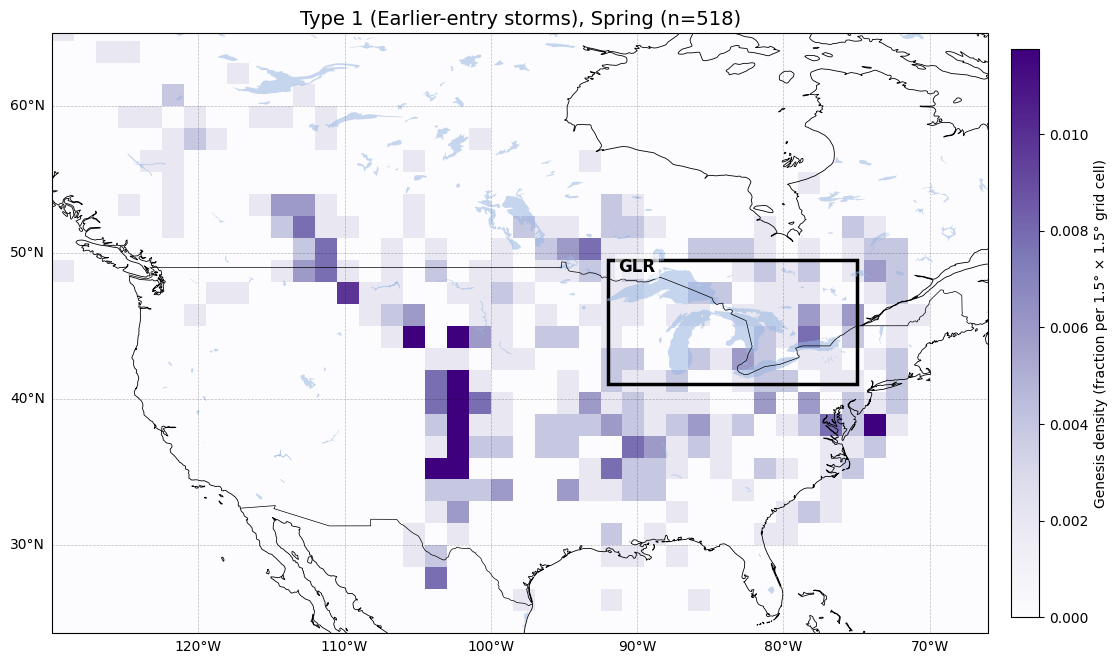

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_mam.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_mam.pdf'))


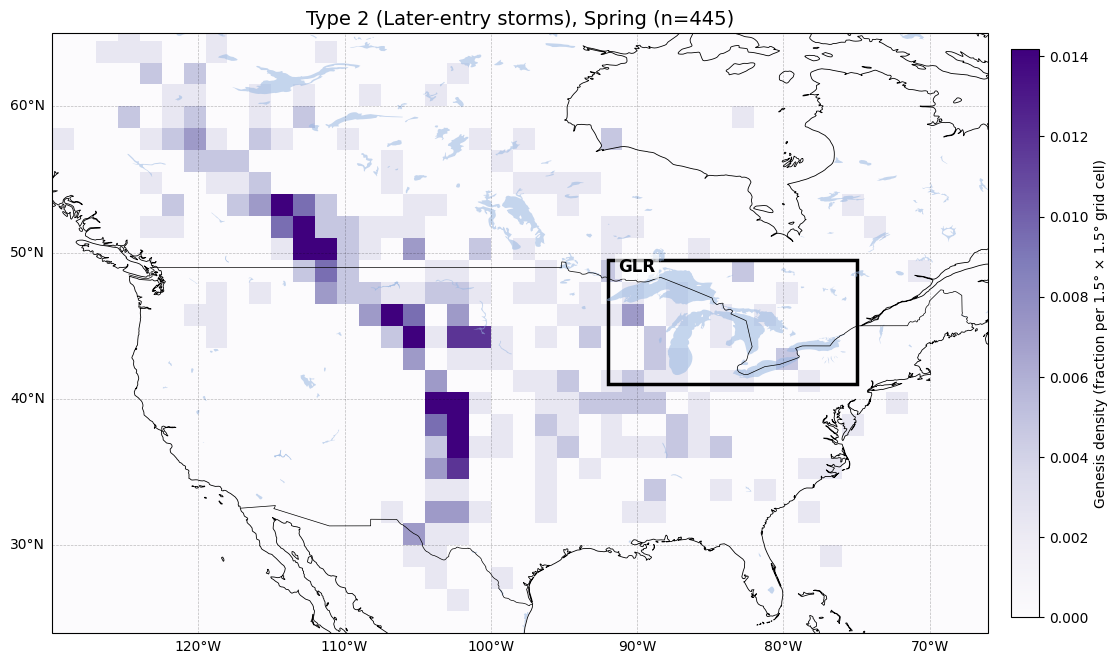

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_mam.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_mam.pdf'))


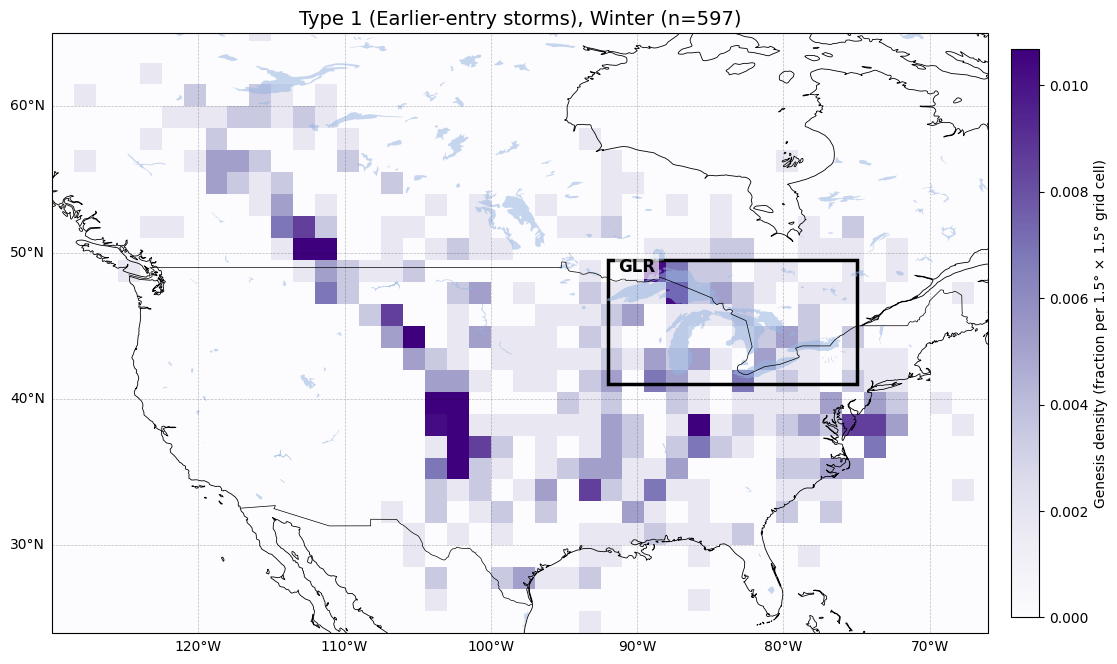

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_djf.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type1_earlier_djf.pdf'))


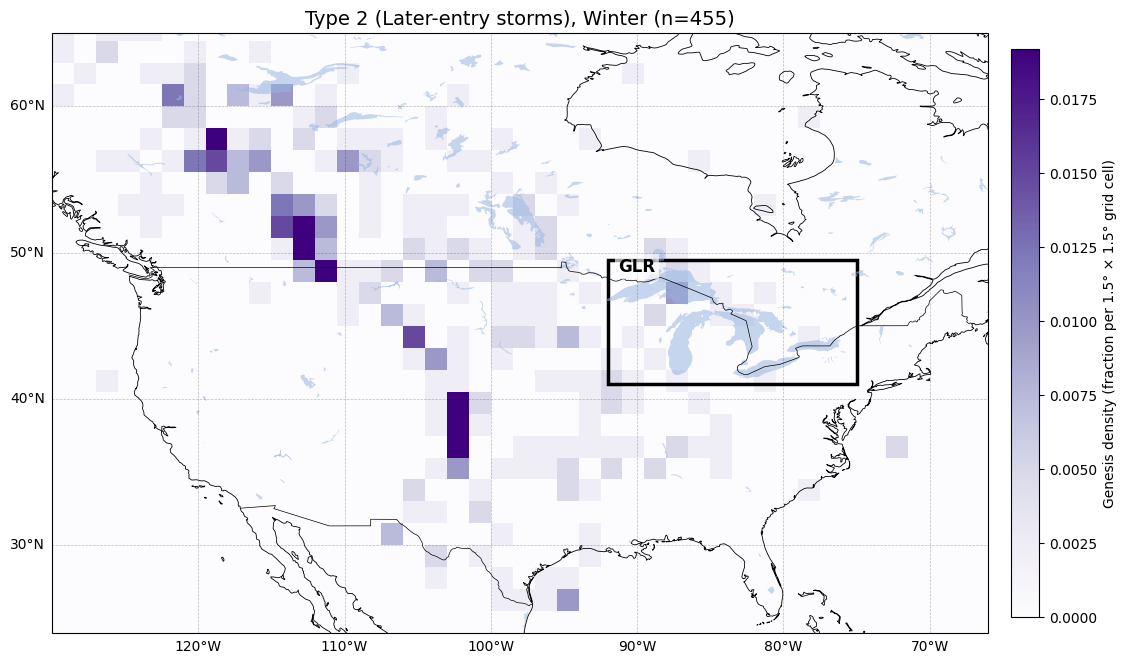

Saved: (PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_djf.png'), PosixPath('/Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig_genesis_density_type2_later_djf.pdf'))


In [9]:
# ------------------------------
# 9. Save one figure per (storm type, season)
# ------------------------------
saved_files = save_all_stormtype_season_figures(
    df,
    seasons=["SON", "JJA", "MAM", "DJF"],
    storm_types=[TYPE1, TYPE2],
    dlon=1.5,
    dlat=1.5,
    smooth_iters=0,
    clip_q=0.97,
    normalize=True,
)

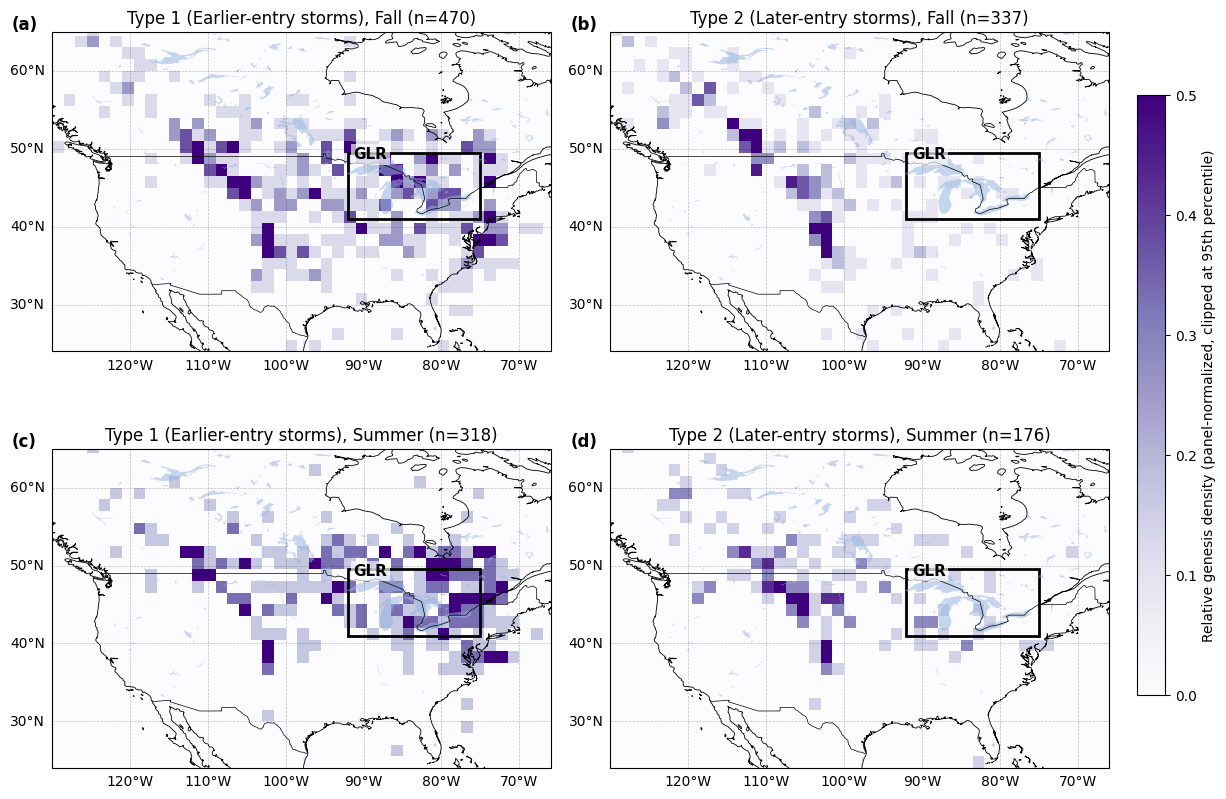

Saved PNG: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig4_genesis_density_2x2_son_jja_panelnorm.png
Saved PDF: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/figures/fig4_genesis_density_2x2_son_jja_panelnorm.pdf


In [10]:
# ------------------------------
# 10. Save 2x2 summary figure
# ------------------------------
png_path, pdf_path = plot_genesis_density_2x2_son_jja(
    df=df,
    seasons=("SON", "JJA"),
    storm_types=(TYPE1, TYPE2),
    dlon=1.5,
    dlat=1.5,
    clip_q=0.95,
    smooth_iters=0,
    scaling="panel",
    filename_base="fig4_genesis_density_2x2_son_jja_panelnorm",
)

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)

## Summary

This notebook generates the Figure 4 genesis-density maps, including both individual seasonal maps and a 2×2 summary panel, and saves both PNG and PDF versions to the `figures/` directory.